# Churn Prediction - Teleco

Customer churn prediction is a critical business problem faced by companies in many industries, particularly those offering subscription-based services. Identifying customers likely to churn allows businesses to proactively implement retention strategies, improving customer loyalty and boosting long-term profitability. This project focuses on predicting customer churn using IBM’s sample dataset of telecom customers.

In this notebook, we will explore and analyze the dataset in depth to identify patterns and correlations between various customer attributes and their likelihood of churning.

The project includes the following:
1. Exploratory Data Analysis (EDA)
2. Data preprocessing
3. Model Selection and Training
4. Evaluation and Insights
5. Business Recommendations

In [14]:
import numpy as np
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import matplotlib.cm as cm
import plotly.express as px
import matplotlib as mtpl
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


plt.style.use('ggplot')
import nltk
df = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

***

## 0. Data Cleaning

In [16]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


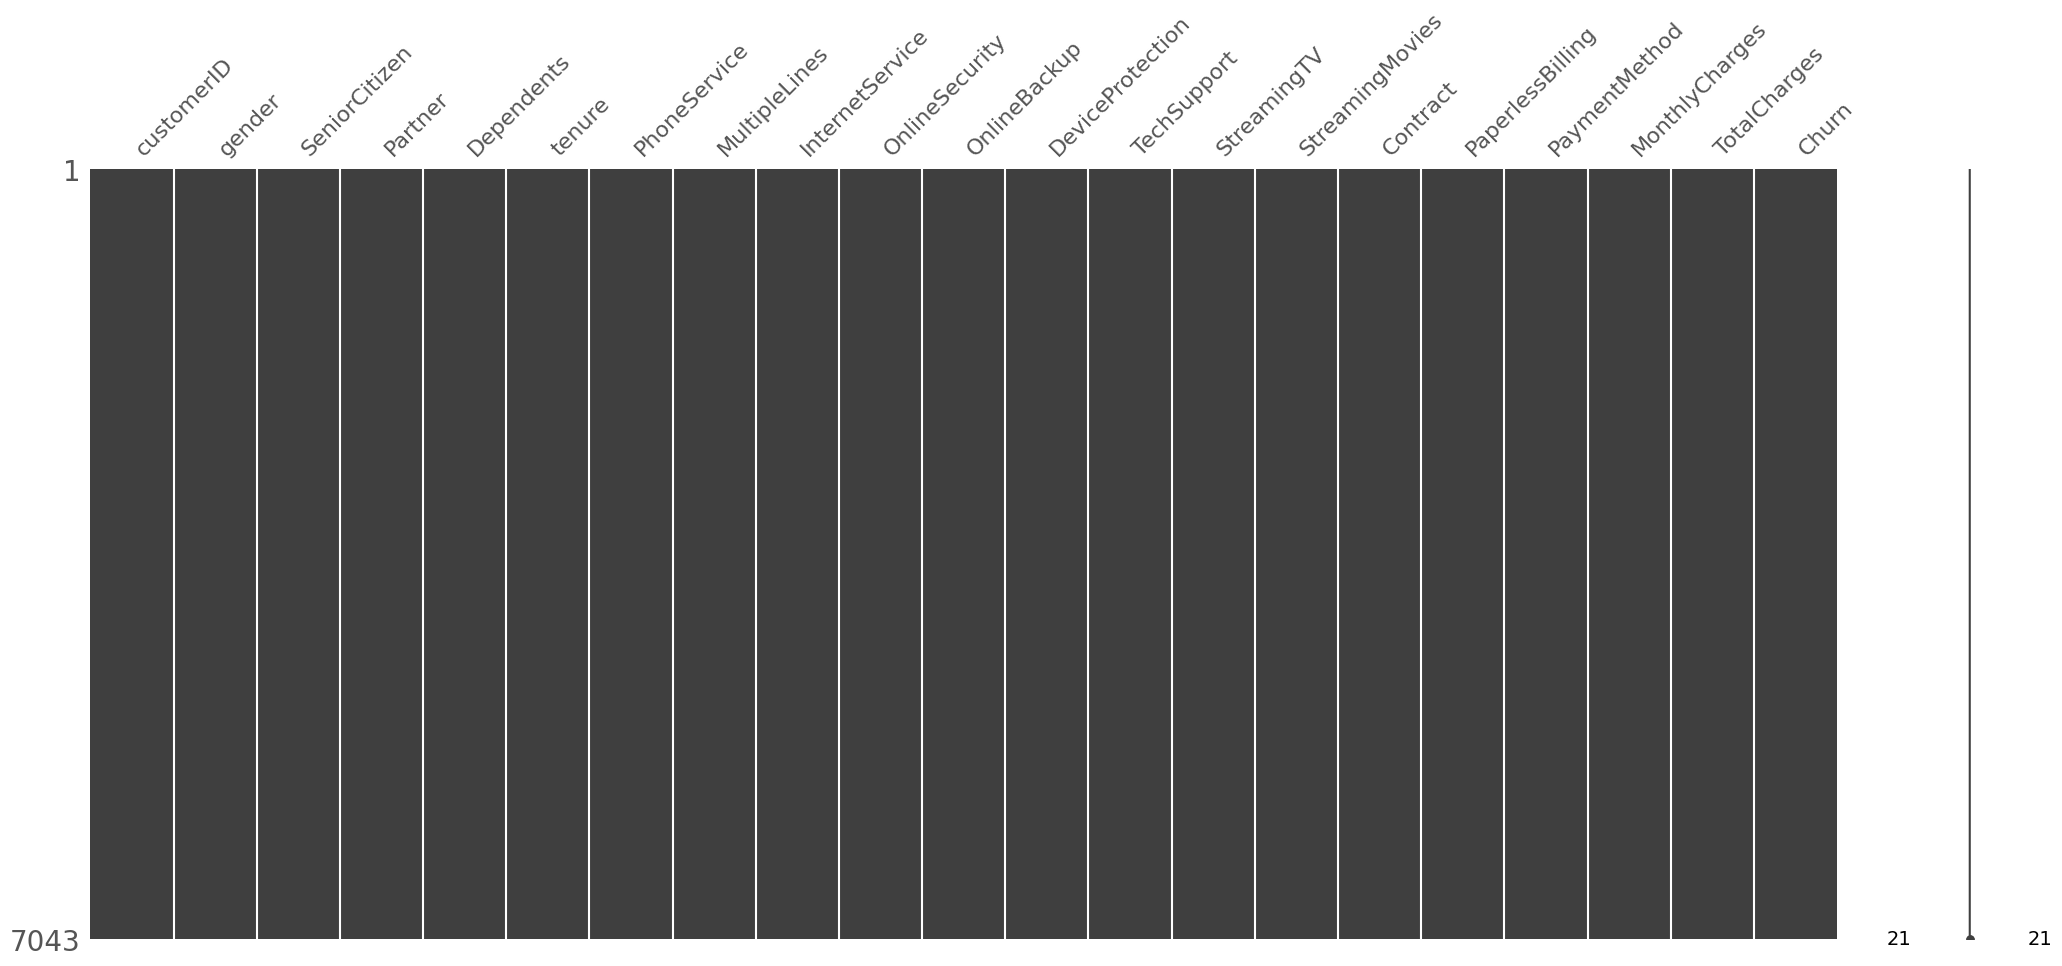

In [18]:
msno.matrix(df);

No null values are present in the data set.

In [19]:
df = df.drop(['customerID'], axis = 1)

In [20]:
df['TotalCharges'] = pd.to_numeric(df.TotalCharges, errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [21]:
df[df['tenure'] == 0]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


There is excatly 11 customers where 'tenure' == 0 and Total Charges are NULL, this implies these costumers have only just joined.
We will eliminate them for the purpose of this analysis.

In [22]:
df.drop(labels=df[df['tenure']==0].index, axis=0, inplace=True)

In [23]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

***

## 1. Exploratory Data Analysis (EDA):

In [24]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numerical_cols].describe()

,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000
mean,32.421786,64.798208,2283.300441
std,24.545260,30.085974,2266.771362
min,1.000000,18.250000,18.800000
25%,9.000000,35.587500,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.862500,3794.737500
max,72.000000,118.750000,8684.800000


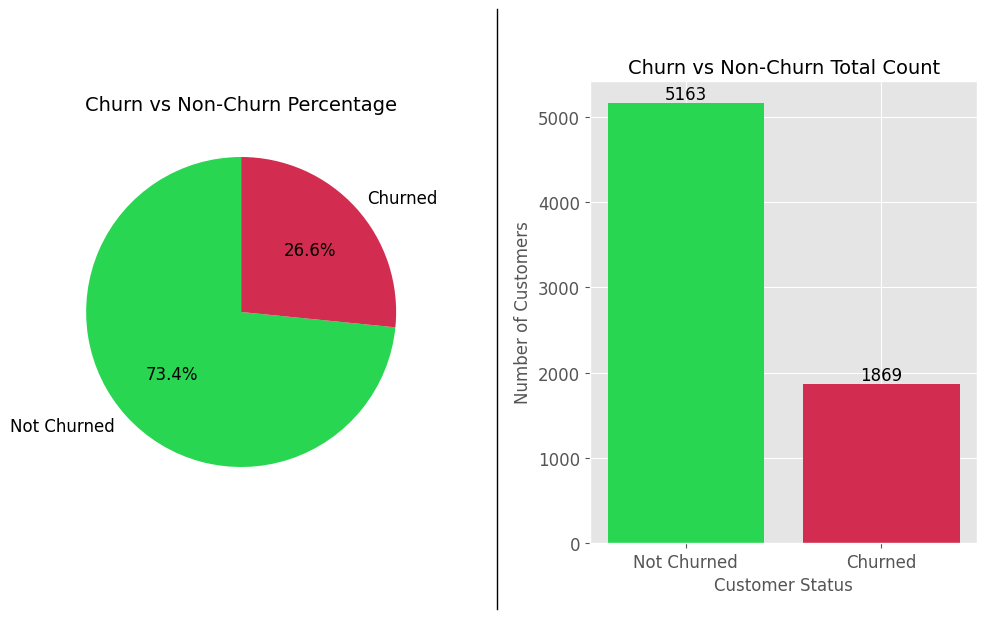

In [25]:
colors = ['#29D651','#D22D50']  

churn_counts = df['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].pie(churn_counts, labels=['Not Churned', 'Churned'], autopct='%1.1f%%',
            startangle=90, colors=colors, textprops={'fontsize': 12})
axes[0].set_title('Churn vs Non-Churn Percentage', fontsize=14)

bars = axes[1].bar(['Not Churned', 'Churned'], churn_counts, color=colors)

for bar in bars:
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width() / 2.0, height, f'{height}',
                 ha='center', va='bottom', fontsize=12)

axes[1].set_title('Churn vs Non-Churn Total Count', fontsize=14)
axes[1].set_ylabel('Number of Customers', fontsize=12)
axes[1].set_xlabel('Customer Status', fontsize=12)
axes[1].tick_params(axis='x', labelsize=12)
axes[1].tick_params(axis='y', labelsize=12)

fig.subplots_adjust(wspace=0.4)
fig.add_artist(plt.Line2D([0.5, 0.5], [0, 1], color='black', linewidth=1, transform=fig.transFigure))

plt.subplots_adjust(wspace=0.4)  
plt.show()

Percentage and total number of churned vs non churned Costumers

In [26]:
l1 = ['gender','SeniorCitizen','Partner','Dependents'] # Demographic Information
l2 = ['PhoneService','MultipleLines','InternetService','StreamingTV','StreamingMovies',
      'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport'] # Services Information
l3 = ['Contract','PaperlessBilling','PaymentMethod'] # Payment Information

Dividing categorical features into groups

### 1.1 Categorical features

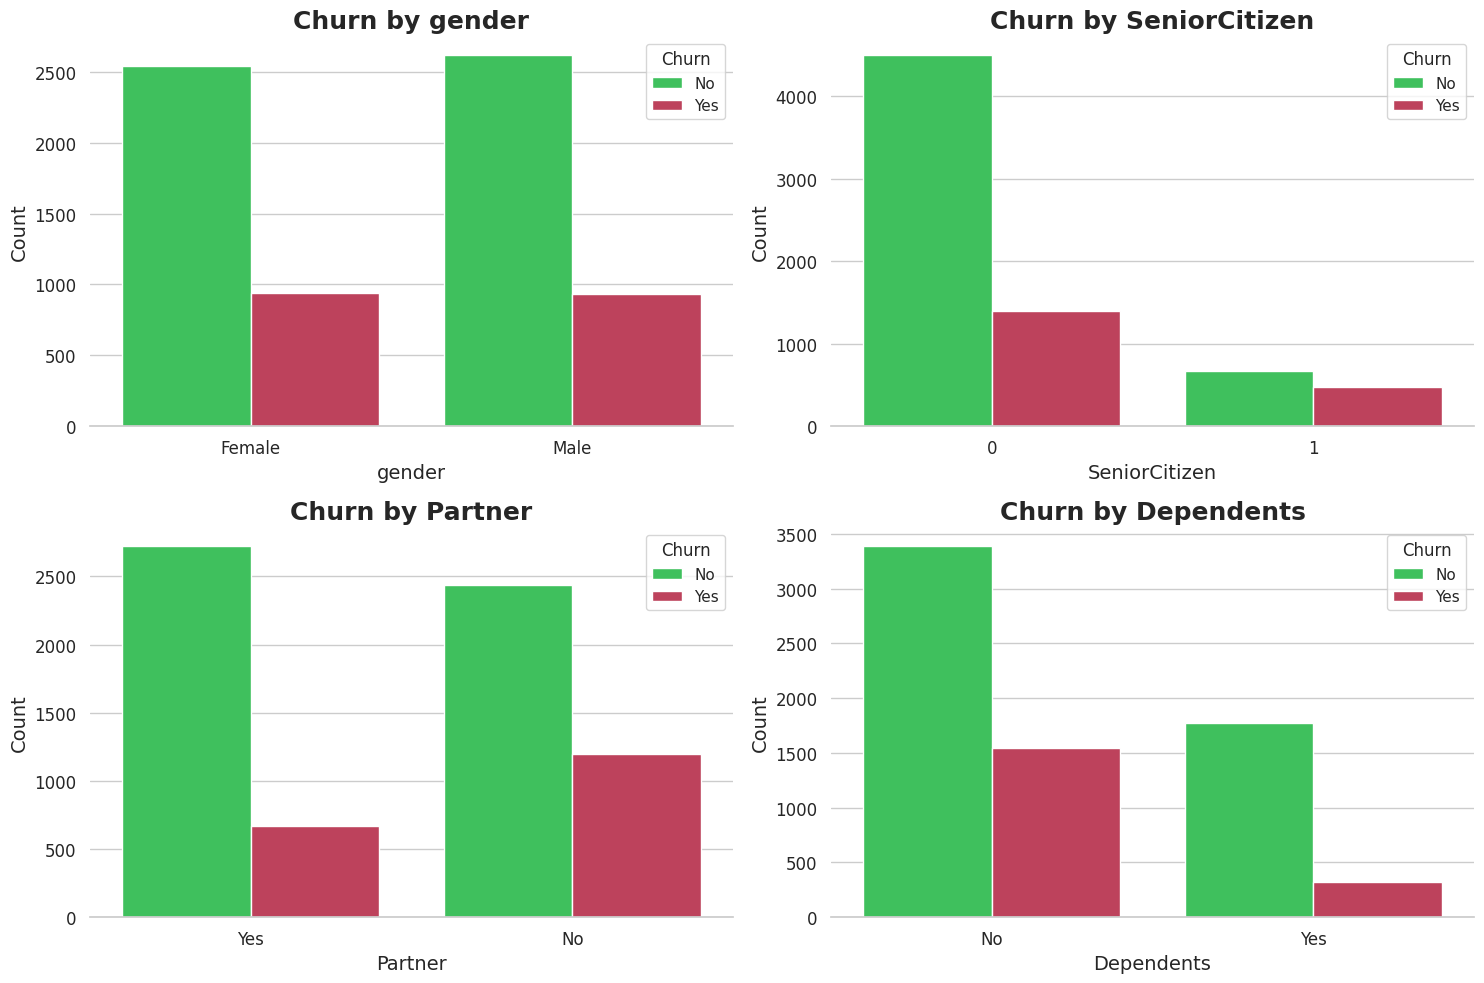

In [27]:
sns.set(style="whitegrid")

n_cols = 2
n_rows = (len(l1) + 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(l1, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.countplot(
        x=col, hue='Churn', data=df, 
        palette=sns.color_palette(colors), edgecolor='white'
    )
    plt.title(f'Churn by {col}', size=18, weight='bold') 
    plt.xlabel(col, size=14)  
    plt.ylabel('Count', size=14)  
    plt.xticks(size=12)  
    plt.yticks(size=12)  
    sns.despine(left=True)  

plt.tight_layout()
plt.show()

Demographic characteristics Churn:
* No significant gender bias in churn behavior is observed
* Senior citizens, while a smaller segment, show a notably higher churn rate proportionally
* Customers with partners (1) show significantly lower churn rates (~20%) than those without partners (0) (~35%)
* The churn rate for customers with dependents is approximately 20%, compared to ~35% for those without

Key Insights for Business Strategy
* Focus on senior citizen retention through targeted programs
* Single customers without dependents represent the highest churn risk segment
* Family-oriented customers (with partners/dependents) show higher loyalty
* Gender-neutral retention strategies may be appropriate given similar churn patterns


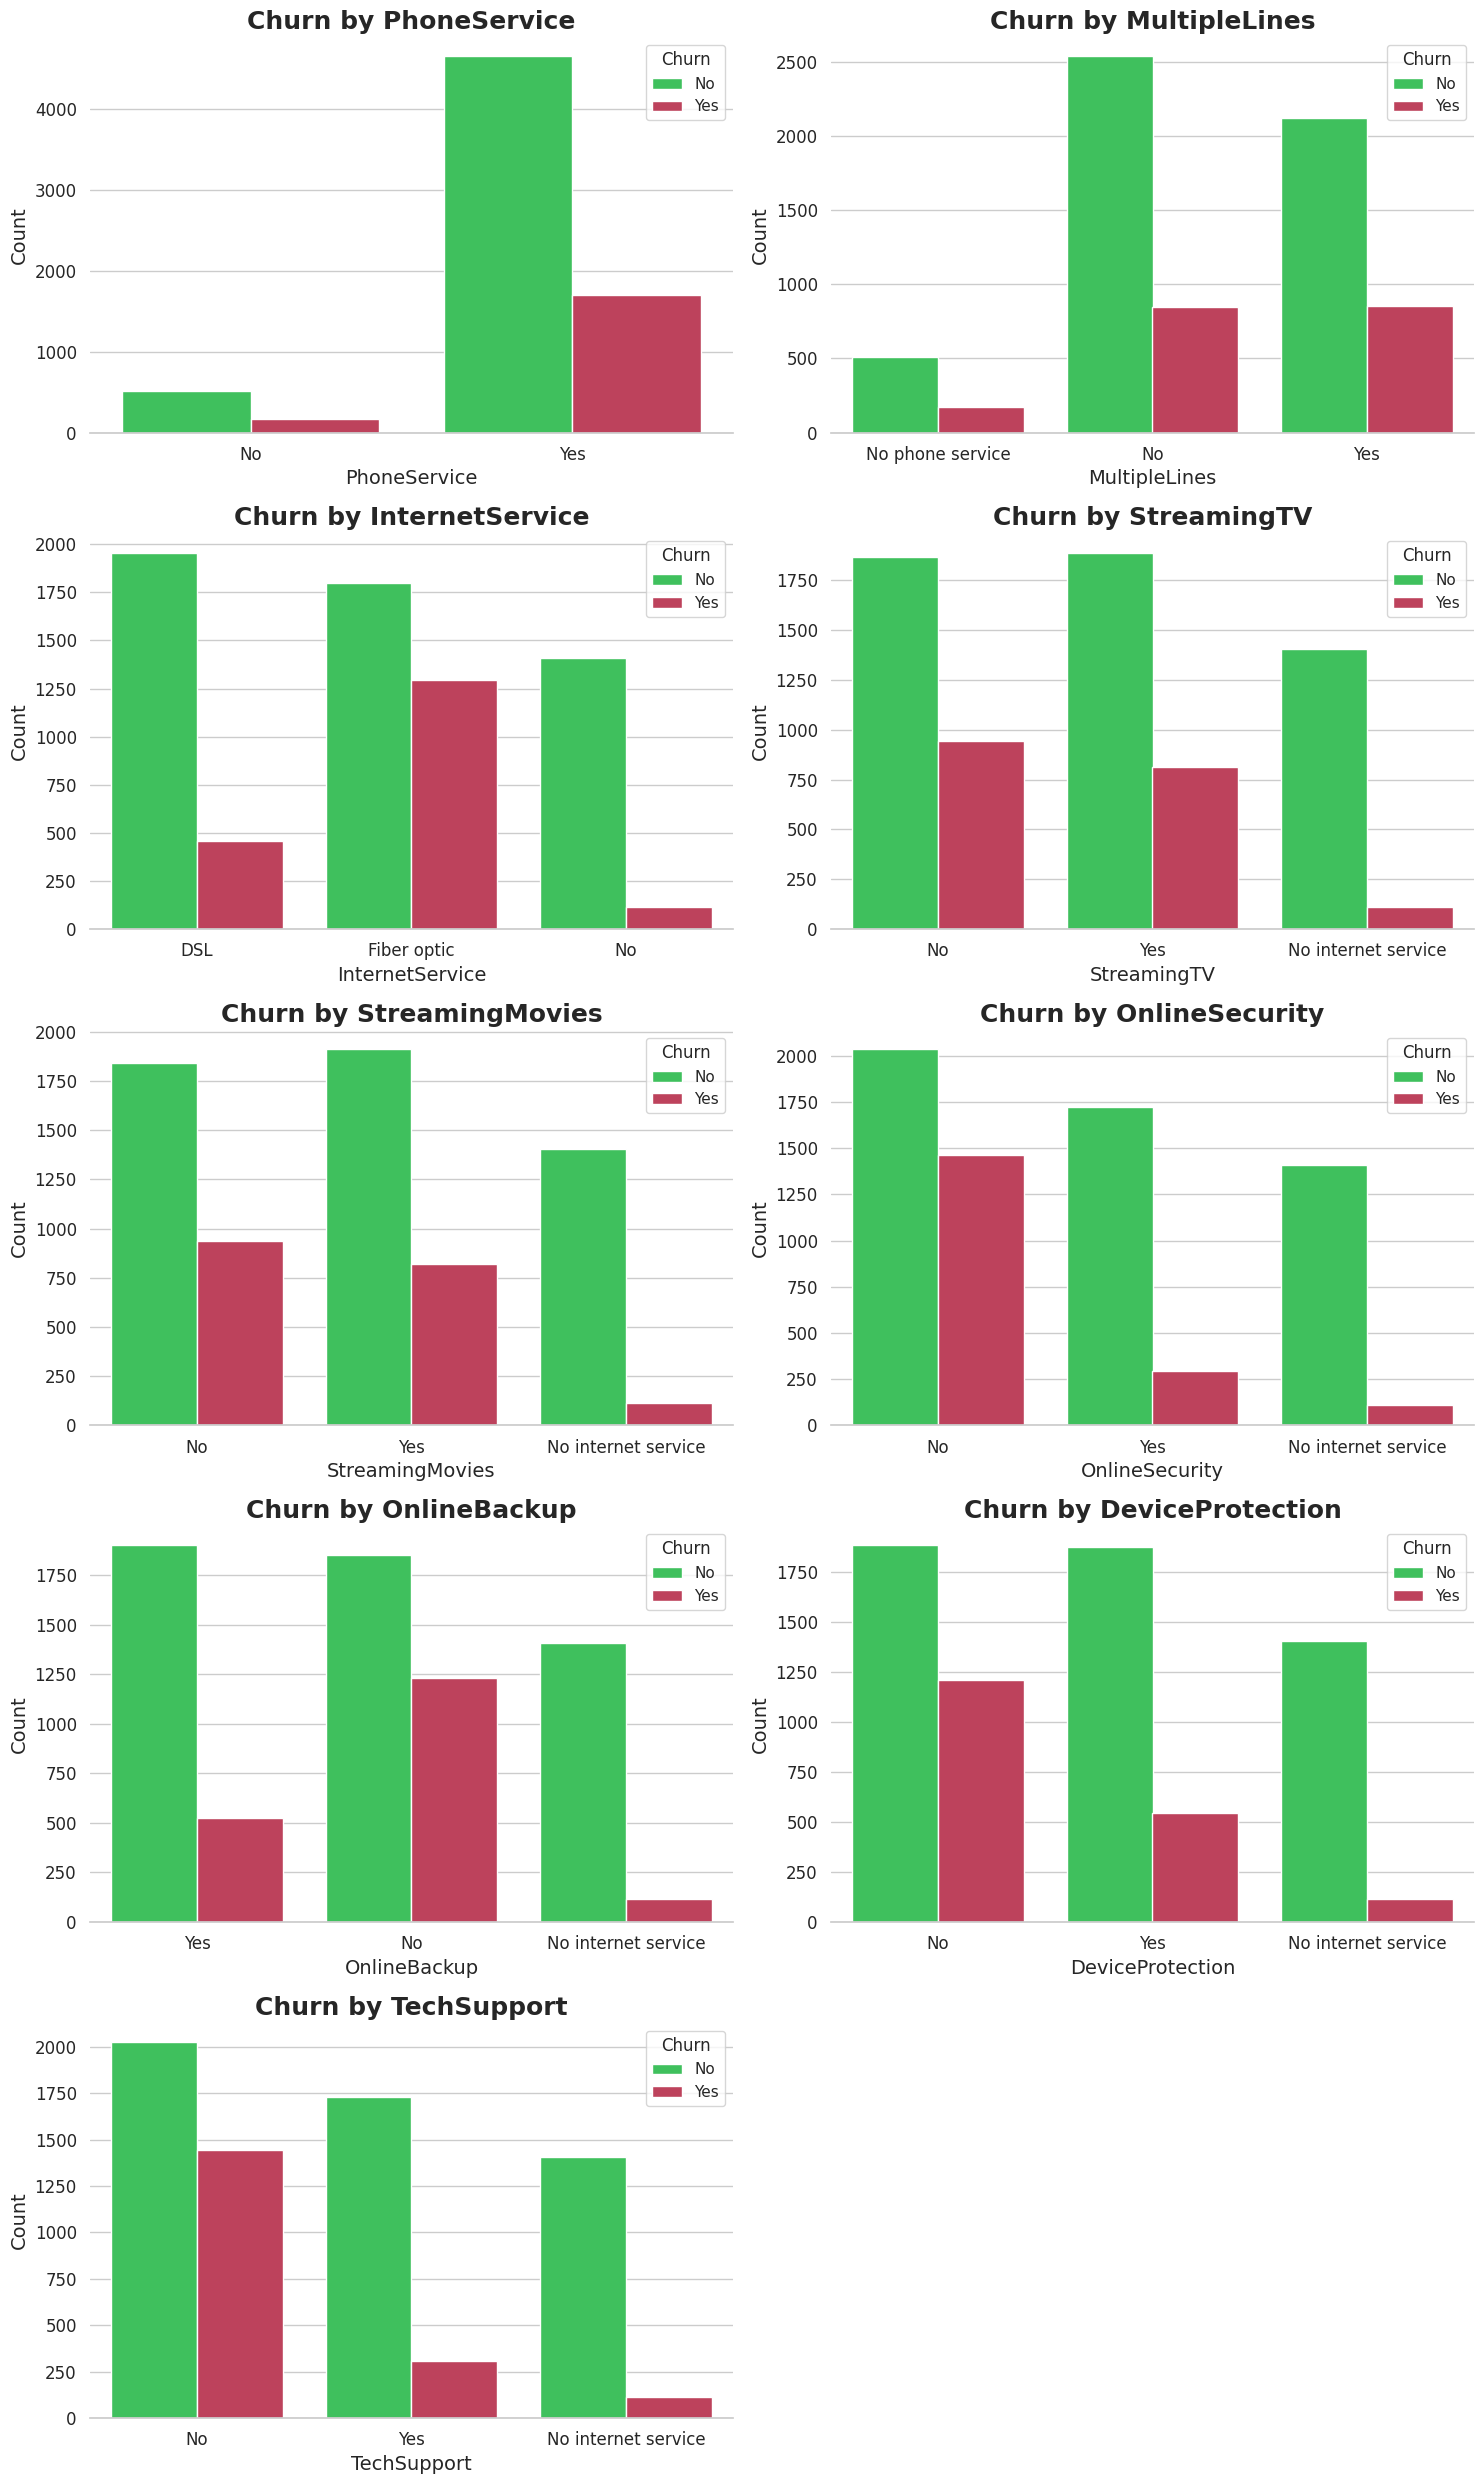

In [28]:
sns.set(style="whitegrid")

n_cols = 2
n_rows = (len(l2) + 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, col in enumerate(l2, 1):
    plt.subplot(n_rows, n_cols, i) 
    sns.countplot(
        x=col, hue='Churn', data=df, 
        palette=colors, edgecolor='white'  
    )
    plt.title(f'Churn by {col}', size=18, weight='bold')
    plt.xlabel(col, size=14)  
    plt.ylabel('Count', size=14)  
    plt.xticks(size=12)  
    plt.yticks(size=12)  
    sns.despine(left=True)  
    
plt.tight_layout()
plt.show()

Services Churn:
* Technical support and security services are crucial for retention
* Bundled services (especially entertainment) correlate with lower churn
* Fiber optic internet service needs investigation for high churn
* Package deals including multiple services may improve retention

Recommendations

Prioritize tech support and security service adoption
Investigate fiber optic service issues
Create attractive service bundles including entertainment options
Focus on upselling additional services to single-service customers


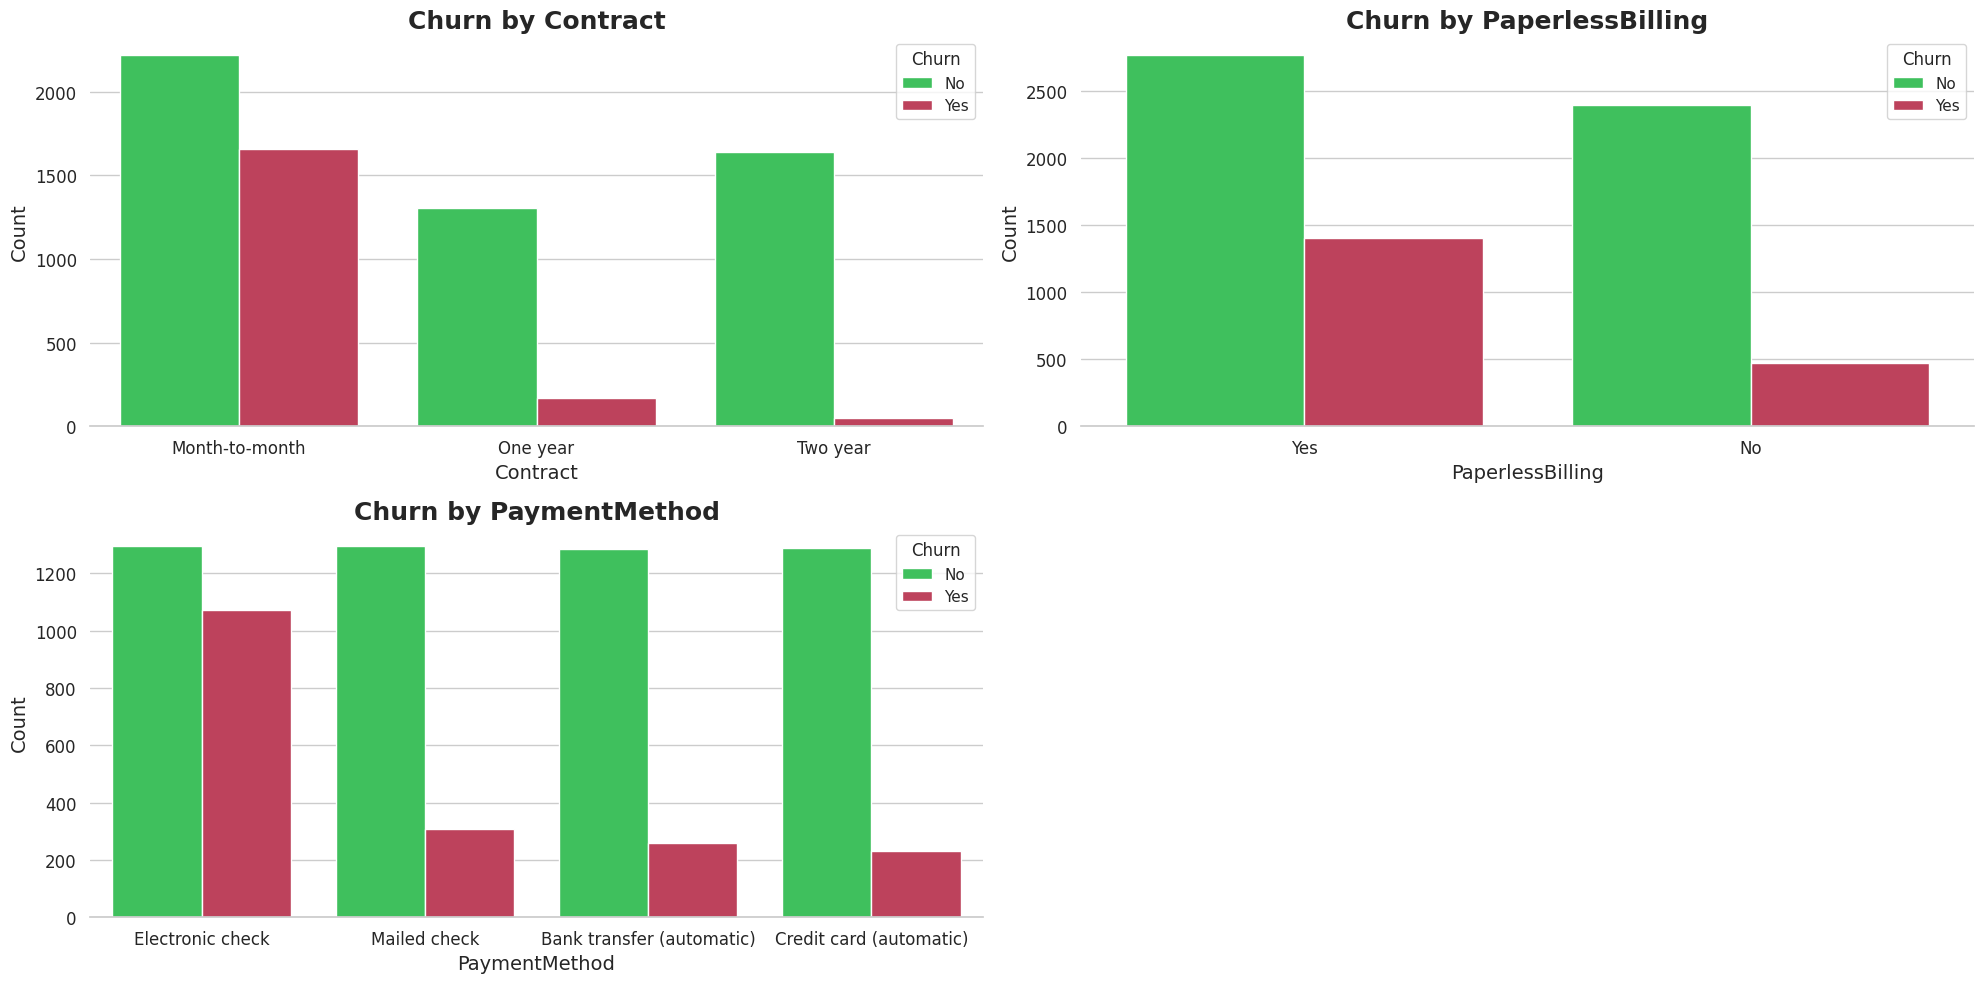

In [29]:
sns.set(style="whitegrid")

n_cols = 2
n_rows = (len(l3) + 1) // n_cols 

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(l3, 1):
    plt.subplot(n_rows, n_cols, i)  
    sns.countplot(
        x=col, hue='Churn', data=df, 
        palette=colors, edgecolor='white'  
    )
    plt.title(f'Churn by {col}', size=18, weight='bold')  
    plt.xlabel(col, size=14)  
    plt.ylabel('Count', size=14)
    plt.xticks(size=12)  
    plt.yticks(size=12)  
    sns.despine(left=True)  

plt.tight_layout()
plt.show()

Payment information Churn:

* Contract length is the strongest predictor of customer retention
* Automatic payment methods correlate with lower churn
* Electronic check payment concerningly high churn

In [30]:
churn_analysis = df.groupby(['PaymentMethod', 'PaperlessBilling', 'Churn']).size().unstack(fill_value=0)

churn_percentages = (churn_analysis.div(churn_analysis.sum(axis=1), axis=0) * 100).round(2)

print("Raw Counts:")
print(churn_analysis)
print("\nChurn Percentages:")
print(churn_percentages)

Raw Counts:
Churn                                        No  Yes
PaymentMethod             PaperlessBilling          
Bank transfer (automatic) No                581   72
                          Yes               703  186
Credit card (automatic)   No                575   64
                          Yes               714  168
Electronic check          No                419  204
                          Yes               875  867
Mailed check              No                820  129
                          Yes               476  179

Churn Percentages:
Churn                                          No    Yes
PaymentMethod             PaperlessBilling              
Bank transfer (automatic) No                88.97  11.03
                          Yes               79.08  20.92
Credit card (automatic)   No                89.98  10.02
                          Yes               80.95  19.05
Electronic check          No                67.26  32.74
                          Yes          

Paperless billing's higher churn stems from Electronic check's higher churn over Mailed check

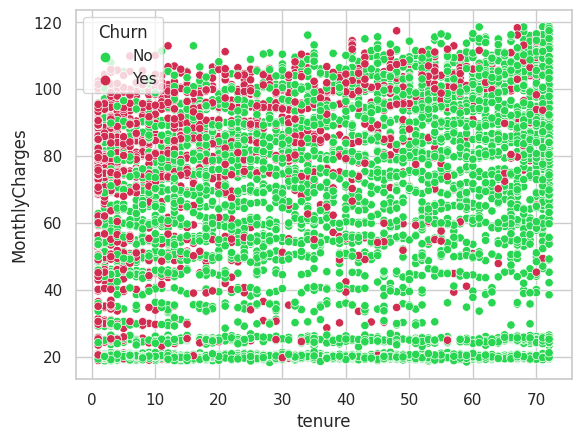

In [31]:
sns.scatterplot(x='tenure',y='MonthlyCharges',data=df,hue='Churn',palette=colors)
plt.show()

* Churn decreases with tenure, most costumers churn early
* Costumers with low monthly charges have low churn regardless of tenure

### 1.2 Numerical analysis

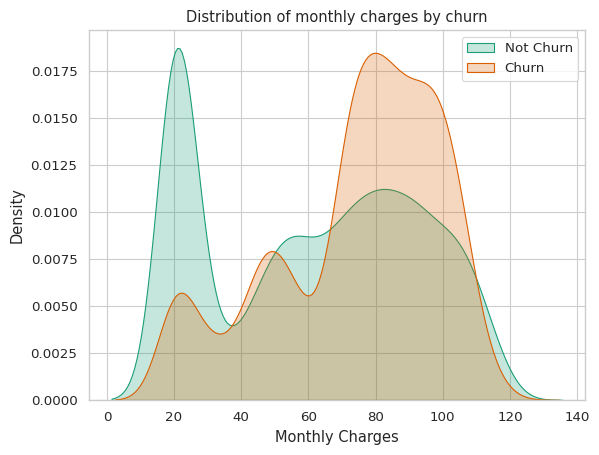

In [32]:
cmap = mtpl.colormaps['Dark2']

sns.set_context("paper",font_scale=1.1)
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'No') ],
                color=cmap(0), fill = True);
ax = sns.kdeplot(df.MonthlyCharges[(df["Churn"] == 'Yes') ],
                ax =ax, color=cmap(1), fill= True);
ax.legend(["Not Churn","Churn"],loc='upper right');
ax.set_ylabel('Density');
ax.set_xlabel('Monthly Charges');
ax.set_title('Distribution of monthly charges by churn');

This density plot of monthly charges shows us several patterns in customer churn:

1. Distinct Pricing Tiers are visible in the distribution:
    * Low tier (20): Shows strong retention, with a high peak of non-churning customers
    * Mid tier (50): Has moderate churn risk
    * High tier (70-100): Shows the highest churn risk, with a pronounced peak in churning customers
      

2. Non-churning customers (green) show a multi-modal distribution with peaks at 20, 50, and 80

3. There might be a price sensitivity threshold around $70 where churn risk increases significantly

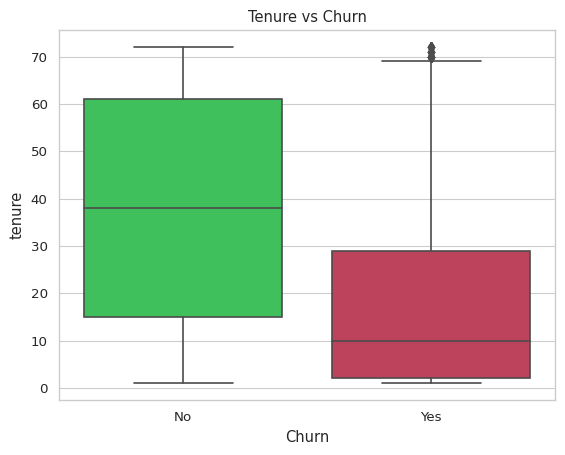

In [33]:
sns.boxplot(x='Churn', y=df['tenure'], data=df, palette=colors)
plt.title('Tenure vs Churn')
plt.show()

Customers are most likely to churn early in their relationship with the company, typically within the first year. Once customers stay beyond this initial period, they're more likely to remain loyal

***

## 2. Data preprocessing

In [34]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

dfE = df.copy(deep = True)

binary_features = ['gender','Partner','Dependents','PhoneService','PaperlessBilling','Churn']
nominal_features = [col for col in df.columns if col not in binary_features and col not in df.describe().columns]
#One hot encoding for nominal features
dfE = pd.get_dummies(df, columns=nominal_features, drop_first=True)
#Label 0/1 encoding for binary feautres
print('Label Encoder Transformation')
for i in binary_features :
    dfE[i] = le.fit_transform(dfE[i])
    print(i,' : ',dfE[i].unique(),' = ',le.inverse_transform(dfE[i].unique()))

Label Encoder Transformation
gender  :  [0 1]  =  ['Female' 'Male']
Partner  :  [1 0]  =  ['Yes' 'No']
Dependents  :  [0 1]  =  ['No' 'Yes']
PhoneService  :  [0 1]  =  ['No' 'Yes']
PaperlessBilling  :  [1 0]  =  ['Yes' 'No']
Churn  :  [0 1]  =  ['No' 'Yes']


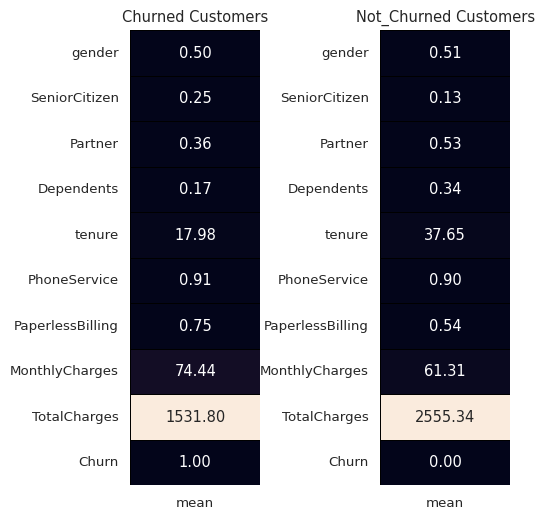

In [35]:
churn = dfE[dfE['Churn'] == 1].describe().T
not_churn = dfE[dfE['Churn'] == 0].describe().T

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (5,5))
plt.subplot(1,2,1)
sns.heatmap(churn[['mean']],annot = True,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f')
plt.title('Churned Customers');

plt.subplot(1,2,2)
sns.heatmap(not_churn[['mean']],annot = True,linewidths = 0.4,linecolor = 'black',cbar = False,fmt = '.2f',)
plt.title('Not_Churned Customers');

fig.tight_layout(pad = 0)

### 2.1 Data Scaling

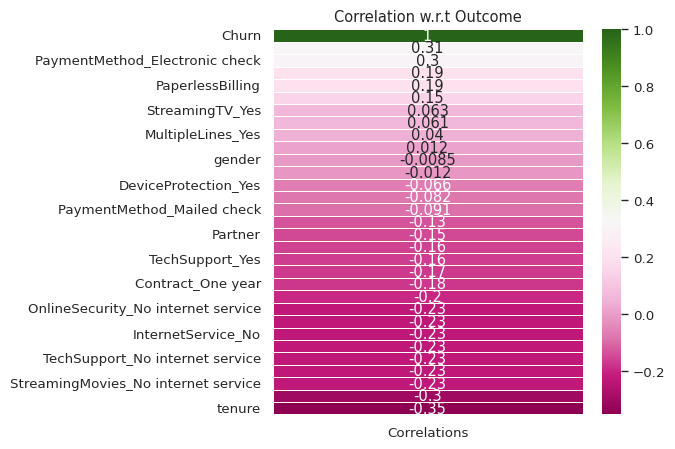

In [37]:
corr = dfE.corrwith(dfE['Churn']).sort_values(ascending = False).to_frame()
corr.columns = ['Correlations']
plt.subplots(figsize = (5,5))
sns.heatmap(corr,annot = True,cmap = 'PiYG',linewidths = 0.4,linecolor = 'white');
plt.title('Correlation w.r.t Outcome');

In [38]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mms = MinMaxScaler() # Normalization
ss = StandardScaler() # Standardization

dfE['tenure'] = mms.fit_transform(dfE[['tenure']])
dfE['MonthlyCharges'] = mms.fit_transform(dfE[['MonthlyCharges']])
dfE['TotalCharges'] = mms.fit_transform(dfE[['TotalCharges']])
dfE.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.000000,0,1,0.115423,0.001275,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,0.464789,1,0,0.385075,0.215867,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,0.014085,1,1,0.354229,0.010310,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,0.619718,0,0,0.239303,0.210241,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,0.014085,1,1,0.521891,0.015330,1,...,False,False,False,False,False,False,False,False,True,False


Most of the algorithms assume the data to be normally distributed, Normalization is done for features whose data does not display normal distribution (tenure, MonthlyCharges and TotalCharges features are normalized )

***

## 3. Model Selection and Training

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import precision_recall_curve

Due to the data being unbalanced (Churn 26% Yes vs 74% No) we need to either undersample or oversample the data.

Since the dataset is already small as it is, we will go with oversampling.

For data balancing, we will use SMOTE.

In [40]:
import imblearn
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

dfE = dfE.astype('float32') 
over = SMOTE(sampling_strategy = 1)
#CHANGE MAYBE to X and y
f1 = dfE.drop(columns=['Churn'])
t1 = dfE['Churn']

f1, t1 = over.fit_resample(f1, t1)
Counter(t1)

x_train, x_test, y_train, y_test = train_test_split(f1, t1, test_size = 0.20, random_state = 12)

In [41]:
def model(classifier,x_train,y_train,x_test,y_test):
    
    classifier.fit(x_train,y_train)
    prediction = classifier.predict(x_test)
    cv = RepeatedStratifiedKFold(n_splits = 10,n_repeats = 3,random_state = 1)
    print("Cross Validation Score : ",'{0:.2%}'.format(cross_val_score(classifier,x_train,y_train,cv = cv,scoring = 'roc_auc').mean()))
    print("ROC_AUC Score : ",'{0:.2%}'.format(roc_auc_score(y_test,prediction)))
    RocCurveDisplay.from_estimator(classifier, x_test, y_test)
    plt.title('ROC_AUC_Plot')
    plt.show()

def model_evaluation(classifier,x_test,y_test):
    
    cm = confusion_matrix(y_test,classifier.predict(x_test))
    names = ['True Neg','False Pos','False Neg','True Pos']
    counts = [value for value in cm.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
    labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names,counts,percentages)]
    labels = np.asarray(labels).reshape(2,2)
    sns.heatmap(cm,annot = labels,cmap = 'YlGn',fmt ='')
    
    print(classification_report(y_test,classifier.predict(x_test)))

### 3.1 XGBClassifier

In [42]:
from xgboost import XGBClassifier

classifier_xgb = XGBClassifier(
    learning_rate=0.05,
    max_depth=8,
    n_estimators=1000,
    colsample_bytree=0.8,       
    alpha=0.5,                   
    min_child_weight=5,           
    gamma=0.1,                   
    scale_pos_weight=1          
)

Cross Validation Score :  93.44%
ROC_AUC Score :  84.31%


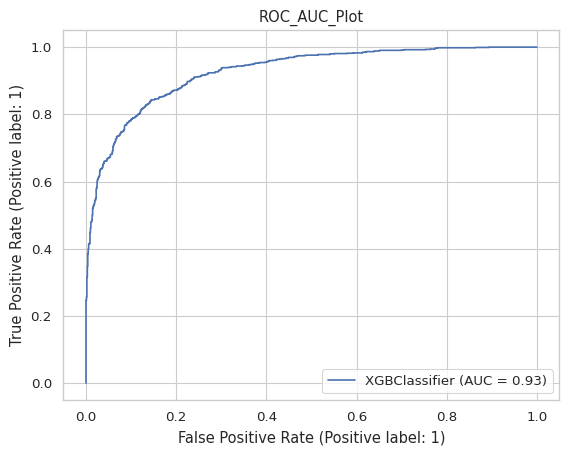

              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84      1020
         1.0       0.84      0.85      0.85      1046

    accuracy                           0.84      2066
   macro avg       0.84      0.84      0.84      2066
weighted avg       0.84      0.84      0.84      2066



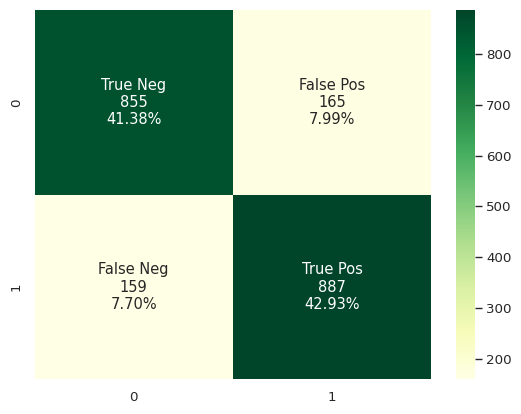

In [43]:
model(classifier_xgb,x_train,y_train,x_test,y_test)
model_evaluation(classifier_xgb,x_test,y_test)

<Figure size 1000x800 with 0 Axes>

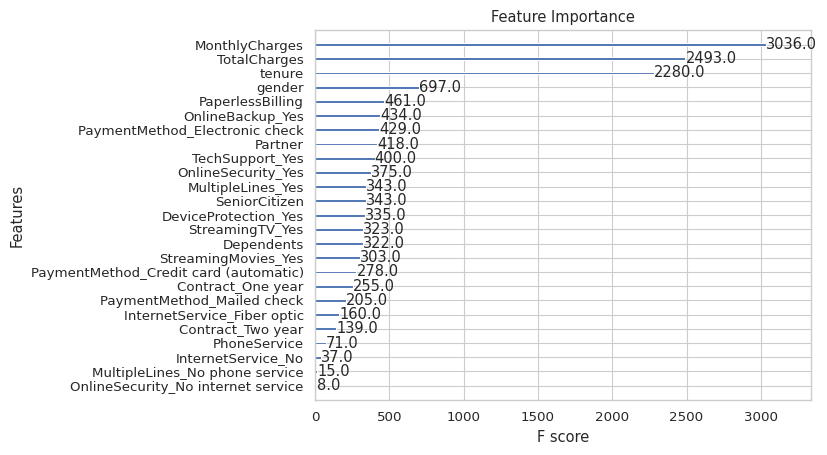

In [44]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(classifier_xgb, max_num_features=25, importance_type='weight')  
plt.title('Feature Importance')
plt.show()

### 3.2 Decisions Tree

In [45]:
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(random_state = 1000,max_depth = 8,min_samples_leaf = 1)

Cross Validation Score :  86.57%
ROC_AUC Score :  79.14%


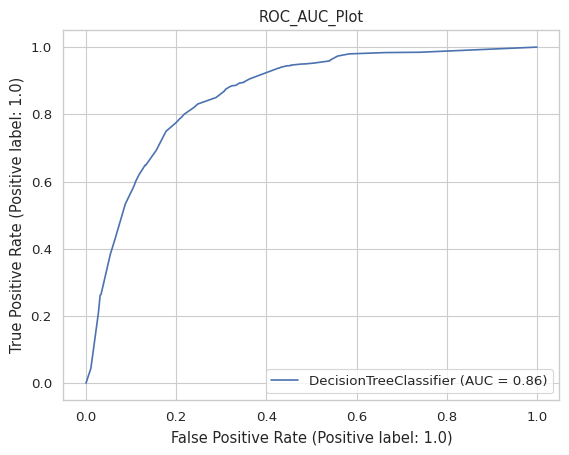

              precision    recall  f1-score   support

         0.0       0.81      0.75      0.78      1020
         1.0       0.77      0.83      0.80      1046

    accuracy                           0.79      2066
   macro avg       0.79      0.79      0.79      2066
weighted avg       0.79      0.79      0.79      2066



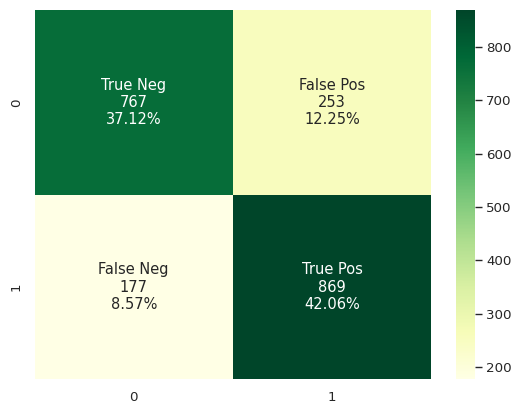

In [46]:
model(classifier_dt,x_train,y_train,x_test,y_test)
model_evaluation(classifier_dt,x_test,y_test)

### 3.3 Forest Classifier

In [47]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(max_depth = 8,random_state = 0)

Cross Validation Score :  89.28%
ROC_AUC Score :  80.43%


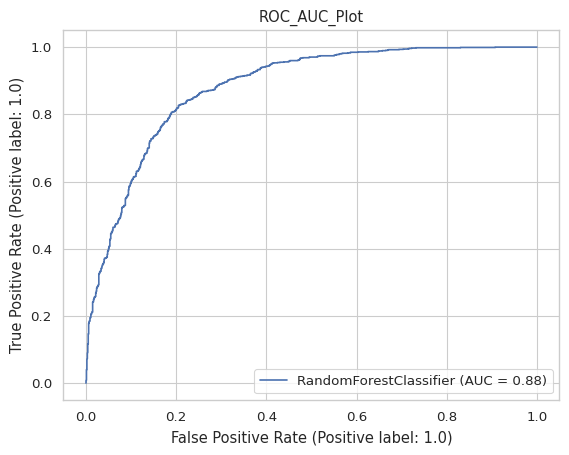

              precision    recall  f1-score   support

         0.0       0.83      0.76      0.79      1020
         1.0       0.78      0.85      0.82      1046

    accuracy                           0.80      2066
   macro avg       0.81      0.80      0.80      2066
weighted avg       0.81      0.80      0.80      2066



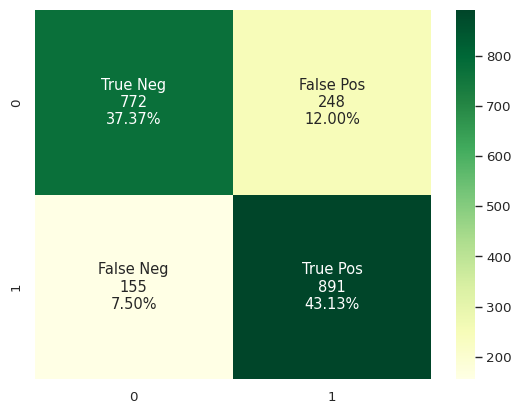

In [48]:
model(classifier_rf,x_train,y_train,x_test,y_test)
model_evaluation(classifier_rf,x_test,y_test)

***

## 4. Evaluation and Interpretation

### 4.1 Model

**XGBClassifier** shows the best overall performance with **93.30% cross-validation** score and **0.93 ROC-AUC**, compared to *89.32% cross-validation* and *0.88 ROC-AUC* for *RandomForestClassifier* and *86.77% cross-validation score* and *0.77 ROC-AUC* for *DecisionTreeClassifier* respecitvely.

XGBClassifier has shown:
* Strong overall accuracy of 85% with balanced performance across classes
* Low false positive rate (7.84%) and false negative rate (7.65%), indicating good reliability
* Confusion matrix with good balance in predictions  

### 4.2 Key Findings

1. **Demographics**

* Senior citizens show higher churn (~40% vs 25% for non-seniors)
* Single customers without dependents are highest risk segment
* Family-oriented customers (with partners/dependents) show higher loyalty

2. **Service Offerings**

* Fiber optic internet shows concerning churn
* Tech support and security services strongly correlate with retention
* Multiple services/bundled packages show better retention rates
* Higher monthly charges ($70-100) correlate with increased churn risk
  
3. **Contract & Payment Structure**

* Month-to-month contracts have ~45% churn vs. 5-15% for longer contracts
* Electronic check + paperless billing combination shows alarmingly high churn (~50%)
* Automatic payments (credit card/bank transfer) show best retention (~10-20% churn)

## 5. Business Recommendations

To improve customer retention, it is essential to consider both churn rates and the overall customer numbers in those segments. The following chapters approaches could lead to a significant decrease in churn:

1. **Contract & Payment Optimization**

* Incentivise month-to-month customers to convert to annual contracts
* Offer discount for switching to automatic payments
* Review paperless billing user experience

2. **Service Package Restructuring**

* Investigate and improve fiber optic service quality
* Create attractive bundled packages at $50-70 price point
* Include tech support and security services in basic packages
* Develop family-oriented service bundles

3. **Customer Support Enhancement**

* Strengthen tech support services
* Create dedicated support team for senior citizens
* Implement proactive support for high-risk segments

4. **Pricing Strategy Revision**

* Review pricing for $70-100 tier services
* Introduce loyalty discounts for long-term customers
* Create competitive family plans
* Develop stepped pricing for contract length commitments